# Healthcare Prescription Safety & Patient Risk Intelligence Platform
 
## Phase 1: MIMIC-IV Data Exploration and Cleaning

### Project overview

Healthcare providers need tools to identify high-risk patients, understand readmission patterns, and support medication safety initiatives.

This notebook focuses on loading, exploring, and assessing the quality of data from the MIMIC-IV Demo dataset.

### Objectives

- Load patient, admission and diagnosis datasets

- Data quality assessment

- Identify missing values and duplicates

- Prepare data for integration with OpenFDA adverse event data

### Dataset

Source: MIMIC-IV Demo Dataset (PhysioNet: "https://physionet.org/content/mimic-iv-demo/2.2/")

Tables used:

- patients

- admissions

- diagnoses_icd

## 1. Import Libraries

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

## 2. Load MIMIC Data

In [2]:
## Load MIMIC Data

patients = pd.read_csv("../data/raw/patients.csv.gz")

admissions = pd.read_csv("../data/raw/admissions.csv.gz")

diagnoses = pd.read_csv("../data/raw/diagnoses_icd.csv.gz")

## 3. Data Inspection

In [3]:
print("PATIENTS")
display(patients.head())

print("ADMISSIONS")
display(admissions.head())

print("DIAGNOSES")
display(diagnoses.head())

PATIENTS


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


ADMISSIONS


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


DIAGNOSES


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


## 4. Dataset Dimension

In [4]:
print(f"Patients: {patients.shape}")
print(f"Admissions: {admissions.shape}")
print(f"Diagnoses: {diagnoses.shape}")

Patients: (100, 6)
Admissions: (275, 16)
Diagnoses: (4506, 5)


## 5. Data Quality Assessment

- Missing values

- Duplicate records

- Data types

#### Data types

In [5]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subject_id         100 non-null    int64
 1   gender             100 non-null    str  
 2   anchor_age         100 non-null    int64
 3   anchor_year        100 non-null    int64
 4   anchor_year_group  100 non-null    str  
 5   dod                31 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [6]:
admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            275 non-null    int64
 1   hadm_id               275 non-null    int64
 2   admittime             275 non-null    str  
 3   dischtime             275 non-null    str  
 4   deathtime             15 non-null     str  
 5   admission_type        275 non-null    str  
 6   admit_provider_id     275 non-null    str  
 7   admission_location    275 non-null    str  
 8   discharge_location    233 non-null    str  
 9   insurance             275 non-null    str  
 10  language              275 non-null    str  
 11  marital_status        263 non-null    str  
 12  race                  275 non-null    str  
 13  edregtime             182 non-null    str  
 14  edouttime             182 non-null    str  
 15  hospital_expire_flag  275 non-null    int64
dtypes: int64(3), str(13

In [7]:
diagnoses.info()

<class 'pandas.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   subject_id   4506 non-null   int64
 1   hadm_id      4506 non-null   int64
 2   seq_num      4506 non-null   int64
 3   icd_code     4506 non-null   str  
 4   icd_version  4506 non-null   int64
dtypes: int64(4), str(1)
memory usage: 176.1 KB


#### Missing values

In [8]:
patients.isnull().sum()

subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64

In [9]:
admissions.isnull().sum()

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64

In [10]:
diagnoses.isnull().sum()

subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64

#### Duplicate check

In [11]:
print("Patients:", patients.duplicated().sum())

print("Admissions:", admissions.duplicated().sum())

print("Diagnoses:", diagnoses.duplicated().sum())

Patients: 0
Admissions: 0
Diagnoses: 0


## 6. Exploratory Data Analysis

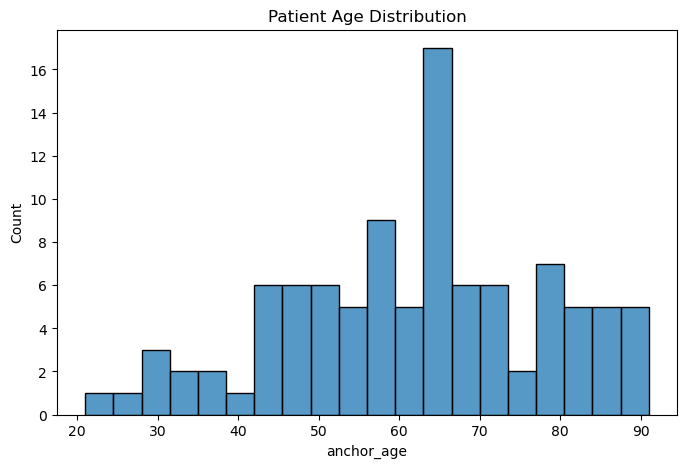

In [12]:
# Patient Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    patients["anchor_age"],
    bins=20
)

plt.title("Patient Age Distribution")

plt.show()

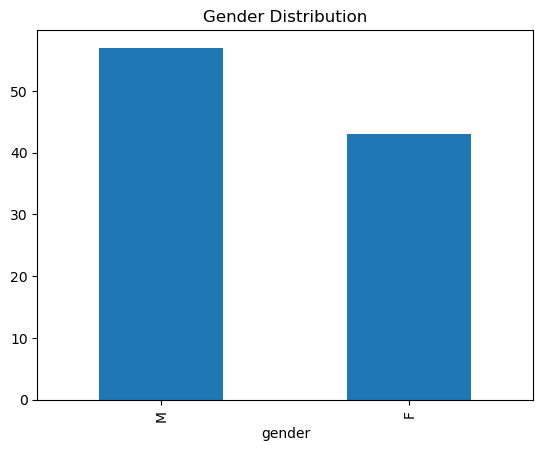

In [13]:
# Gender Distribution

patients["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.show()

## 7. Export Cleaned Datasets

In [ ]:
patients.to_csv(
    "../data/processed/patients_clean.csv",
    index=False
)

admissions.to_csv(
    "../data/processed/admissions_clean.csv",
    index=False
)

diagnoses.to_csv(
    "../data/processed/diagnoses_clean.csv",
    index=False
)